**Investments: Theory and Data Analysis**, Bates, Boyer, and Fletcher

# Chapter 6: A Short Introduction to Matplotlib

Matplotlib is the Python package we use to visualize financial data. This notebook introduces the basic plotting patterns you will need for the Chapter 6 Ken French data lab: creating a figure, adding axes, plotting a time series, making a histogram, comparing multiple series, and labeling a chart. The examples use a small, reproducible set of made-up monthly returns.

## Learning objectives

By the end of this notebook, you should be able to:

- Import Matplotlib using the standard `plt` alias.
- Create a figure and an axes object.
- Plot a time series with labels, a title, and a legend.
- Use a histogram to examine the distribution of returns.
- Create multiple plots with `subplots`.
- Explain how the same commands apply to Ken French portfolio data.

## Figures and axes

Matplotlib uses two important objects:

- A **figure** is the overall canvas.
- An **axes** object is one plotting area inside the figure.

The most flexible pattern is `fig, ax = plt.subplots()`. We then call methods on `ax`, such as `ax.plot(...)`, `ax.set_title(...)`, and `ax.legend(...)`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Create reproducible, made-up monthly returns.
rng = np.random.default_rng(6)
dates = pd.date_range('2020-01-31', periods=36, freq='ME')
portfolio_returns = pd.DataFrame(
    {
        'Low-momentum': rng.normal(0.006, 0.045, len(dates)),
        'High-momentum': rng.normal(0.009, 0.045, len(dates)),
    },
    index=dates
)

portfolio_returns.head()

,Low-momentum,High-momentum
2020-01-31,0.053390,-0.001125
2020-02-29,0.085942,-0.021623
2020-03-31,-0.108898,0.035895
2020-04-30,-0.000208,0.010615
2020-05-31,0.051617,-0.029802


## Plot a time series

A line chart is useful when the order of observations matters, as it does for monthly returns or cumulative wealth. The `ax.plot` method accepts the dates as the horizontal values and a Series as the vertical values.

The values in this example are decimals, so `PercentFormatter(1.0)` displays `0.05` as 5%.

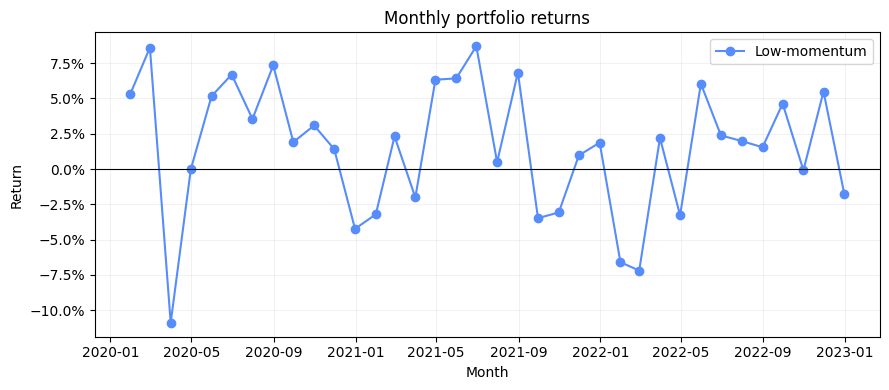

In [2]:
# Create a figure and one plotting area, with a wide layout for a time series.
fig, ax = plt.subplots(figsize=(9, 4))

# Plot the dates on the horizontal axis and the portfolio returns on the vertical axis.
ax.plot(
    portfolio_returns.index,
    portfolio_returns['Low-momentum'],
    label='Low-momentum',
    marker='o',
    linewidth=1.5,
)
# Add descriptive labels so the chart explains what is being shown.
ax.set_title('Monthly portfolio returns')
ax.set_xlabel('Month')
ax.set_ylabel('Return')
# Display decimal returns as percentages; 1.0 represents 100%.
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
# Add a horizontal reference line at zero return.
ax.axhline(0, color='black', linewidth=0.8)
# Add a light grid and a legend to make the plot easier to read.
ax.grid(alpha=0.25)
ax.legend()
# Adjust spacing, then display the completed figure.
fig.tight_layout()
plt.show()

## Compare two portfolios

Call `ax.plot` more than once to place multiple series on the same axes. A legend identifies each line. The `DataFrame.plot` method can also create a similar chart, but the explicit Matplotlib pattern makes it clear which figure and axes are being modified.

In [ ]:
# Create a figure and one plotting area for the comparison.
fig, ax = plt.subplots(figsize=(9, 4))

# Plot the low-momentum portfolio as the first line.
ax.plot(
    portfolio_returns.index,
    portfolio_returns['Low-momentum'],
    label='Low-momentum',
)

# Plot the high-momentum portfolio as the second line.
ax.plot(
    portfolio_returns.index,
    portfolio_returns['High-momentum'],
    label='High-momentum',
)

# Add descriptive labels to identify the data and units.
ax.set_title('Comparing monthly portfolio returns')
ax.set_xlabel('Month')
ax.set_ylabel('Return')
# Display decimal returns as percentages; 1.0 represents 100%.
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
# Add a zero-return reference line, grid, and legend.
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(alpha=0.25)
ax.legend()
# Adjust spacing, then display the completed figure.
fig.tight_layout()
plt.show()

## Plot cumulative wealth

Investors often care about the path of one dollar invested over time. If returns are reinvested, cumulative wealth is calculated with the cumulative product of `1 + return`. This is the same calculation used in the Ken French lab.

In [ ]:
# Reinvest each month's return to calculate the value of one dollar over time.
cumulative_wealth = (1 + portfolio_returns).cumprod()

# Create a figure and one plotting area for the wealth comparison.
fig, ax = plt.subplots(figsize=(9, 4))

# Plot the low-momentum portfolio's cumulative wealth.
ax.plot(
    cumulative_wealth.index,
    cumulative_wealth['Low-momentum'],
    label='Low-momentum',
)

# Plot the high-momentum portfolio's cumulative wealth.
ax.plot(
    cumulative_wealth.index,
    cumulative_wealth['High-momentum'],
    label='High-momentum',
)

# Add descriptive labels to identify the data and units.
ax.set_title('Growth of one dollar')
ax.set_xlabel('Month')
ax.set_ylabel('Dollars')
# Add a light grid and a legend to make the lines easier to compare.
ax.grid(alpha=0.25)
ax.legend()
# Adjust spacing, then display the completed figure.
fig.tight_layout()
plt.show()

## Plot a return distribution

A histogram groups observations into bins. It helps us see the center, spread, and shape of realized returns. The vertical line marks the sample mean.

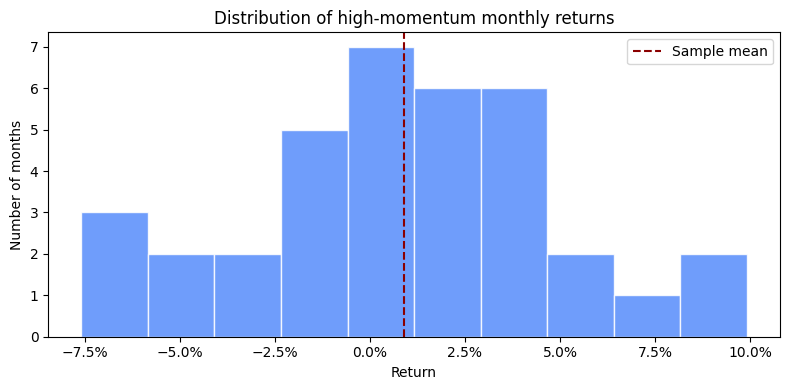

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    portfolio_returns['High-momentum'],
    bins=10,
    edgecolor='white',
    alpha=0.85,
)
ax.axvline(
    portfolio_returns['High-momentum'].mean(),
    color='darkred',
    linestyle='--',
    label='Sample mean',
)
ax.set_title('Distribution of high-momentum monthly returns')
ax.set_xlabel('Return')
ax.set_ylabel('Number of months')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend()
fig.tight_layout()
plt.show()

## Arrange multiple plots with subplots

`plt.subplots` can create several axes in one figure. Here we place a time-series plot beside a histogram. The `axes` object is an array of axes, so we use `axes[0]` and `axes[1]` to address the two plotting areas.

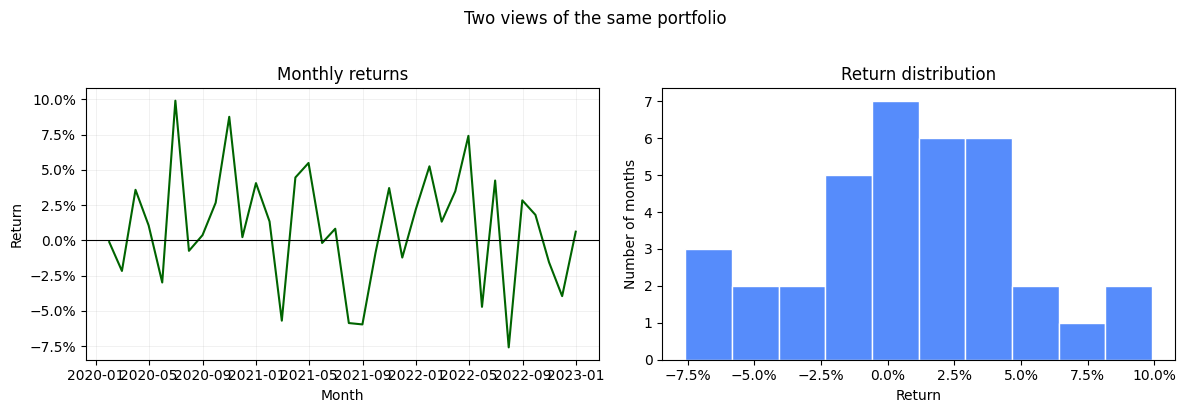

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    portfolio_returns.index,
    portfolio_returns['High-momentum'],
    color='darkgreen',
)
axes[0].set_title('Monthly returns')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Return')
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].grid(alpha=0.25)

axes[1].hist(portfolio_returns['High-momentum'], bins=10, edgecolor='white')
axes[1].set_title('Return distribution')
axes[1].set_xlabel('Return')
axes[1].set_ylabel('Number of months')
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))

fig.suptitle('Two views of the same portfolio', y=1.02)
fig.tight_layout()
plt.show()

## A preview of the Ken French workflow

In the Ken French lab, the data-loading function returns a Pandas DataFrame. After selecting portfolio columns, you can use the same plotting pattern:

```python
fig, ax = plt.subplots(figsize=(8, 4))
for column in selected_portfolios:
    ax.plot(portfolio_returns.index, portfolio_returns[column], label=column)
ax.set_title('Ken French portfolio returns')
ax.legend()
plt.show()
```

Good charts identify what is being measured, the units, the time period, and the series being compared.

## Key terms

- **Figure:** the overall canvas containing one or more plots.
- **Axes:** one plotting area inside a figure.
- **Line chart:** a chart that shows how a variable changes across an ordered axis, such as time.
- **Histogram:** a chart that groups observations into intervals to show a distribution.
- **Legend:** a key that identifies the plotted series.

## Next step

Open `Ex06-Ken French_Portfolio_Returns.ipynb` next. Use the Pandas skills from `Ex06-pandas_intro.ipynb` to inspect and summarize the downloaded DataFrame, and use the Matplotlib skills from this notebook to visualize its return distributions and cumulative wealth.